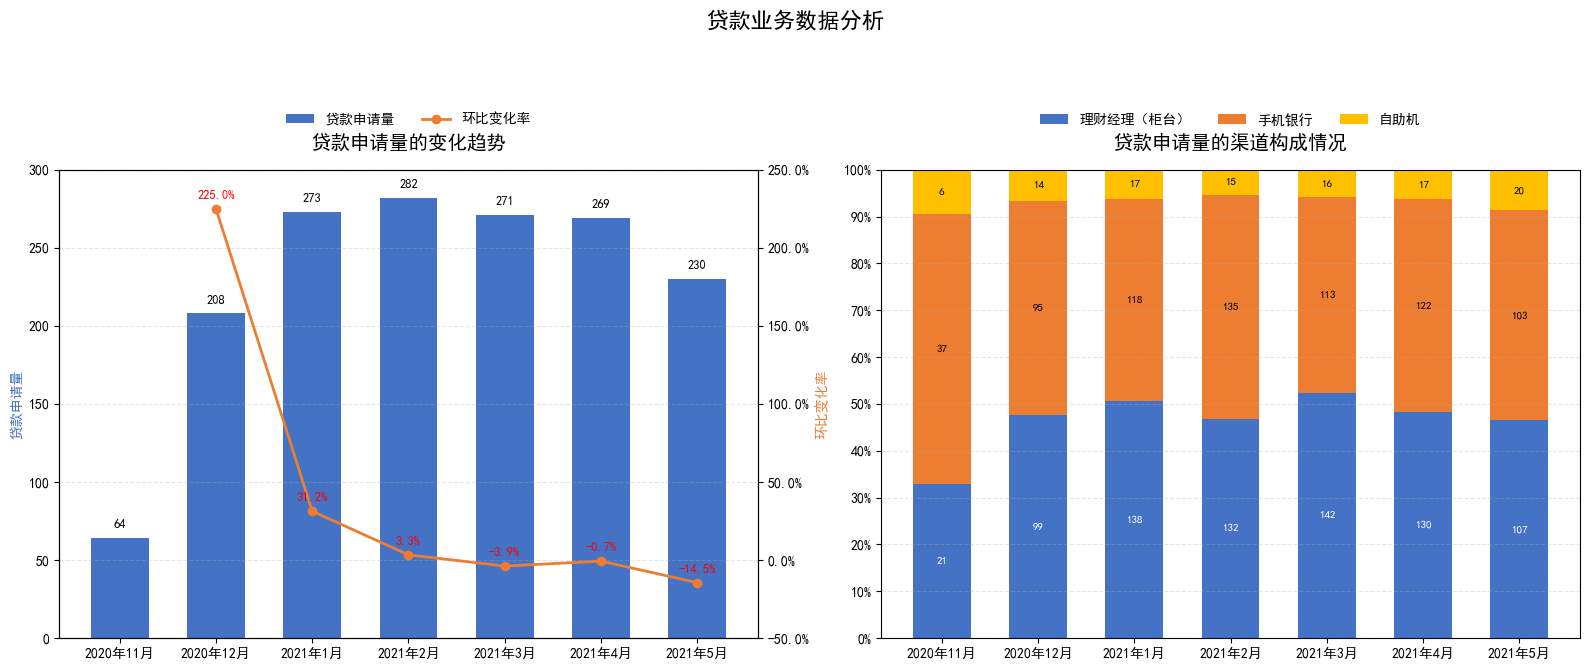

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ================= 1. 全局设置 =================
# 设置中文字体 (Windows用SimHei，Mac用Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# Excel 经典配色
color_blue = '#4472C4'   # 理财经理/贷款量
color_orange = '#ED7D31' # 手机银行/环比
color_yellow = '#FFC000' # 自助机

# ================= 2. 数据准备 =================
months = ['2020年11月', '2020年12月', '2021年1月', '2021年2月', '2021年3月', '2021年4月', '2021年5月']

# 图1数据
loan_volume = [64, 208, 273, 282, 271, 269, 230]
# 环比变化率 (第一个月无环比，设为None或0，绘图时从第二个点开始)
growth_rate = [None, 2.25, 0.3125, 0.033, -0.039, -0.0074, -0.145] 
# 为了绘图方便，将None替换为0，但在画图时只画后6个点
growth_rate_plot = [0, 2.25, 0.3125, 0.033, -0.039, -0.0074, -0.145]

# 图2数据 (渠道构成)
manager = [21, 99, 138, 132, 142, 130, 107]      # 理财经理
mobile = [37, 95, 118, 135, 113, 122, 103]       # 手机银行
machine = [6, 14, 17, 15, 16, 17, 20]            # 自助机
total = [64, 208, 273, 282, 271, 269, 230]       # 总计

# ================= 3. 绘图 =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('贷款业务数据分析', fontsize=16, fontweight='bold', y=0.95)

# --- 图1：贷款申请量的变化趋势 (双轴图) ---
x_pos = np.arange(len(months))
width = 0.6

# 左轴：柱状图 (贷款申请量)
ax1_bar = ax1.bar(x_pos, loan_volume, width, color=color_blue, label='贷款申请量', zorder=2)
ax1.set_ylim(0, 300)
ax1.set_yticks(range(0, 301, 50))
ax1.set_ylabel('贷款申请量', color=color_blue)

# 在柱子上方添加数值标签
for i, v in enumerate(loan_volume):
    ax1.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=9)

# 右轴：折线图 (环比变化率)
ax2_twin = ax1.twinx()
# 注意：折线从第二个月开始画 (索引1到6)
ax2_twin.plot(x_pos[1:], growth_rate_plot[1:], color=color_orange, marker='o', linewidth=2, label='环比变化率', zorder=3)
ax2_twin.set_ylim(-0.5, 2.5) # -50% 到 250%
ax2_twin.set_yticks([-0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5])
# 格式化右轴为百分比
ax2_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
ax2_twin.set_ylabel('环比变化率', color=color_orange)
ax2_twin.grid(axis='y', linestyle='--', alpha=0.3, zorder=1) # 网格线

# 添加环比数据标签 (红色字体)
for i in range(1, len(months)):
    val = growth_rate_plot[i]
    # 标签位置稍微偏上
    ax2_twin.text(i, val + 0.05, '{:.1%}'.format(val), ha='center', va='bottom', color='red', fontsize=9)

# 设置X轴
ax1.set_xticks(x_pos)
ax1.set_xticklabels(months, rotation=0)
ax1.set_title('贷款申请量的变化趋势', fontsize=14, pad=15)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)


# --- 图2：贷款申请量的渠道构成情况 (百分比堆积图) ---
x_pos2 = np.arange(len(months))
width2 = 0.6

# 计算百分比高度
p_manager = np.array(manager) / np.array(total) * 100
p_mobile = np.array(mobile) / np.array(total) * 100
p_machine = np.array(machine) / np.array(total) * 100

# 绘制堆积柱状图
# 底层：理财经理
bar1 = ax2.bar(x_pos2, p_manager, width2, color=color_blue, label='理财经理（柜台）')
# 中层：手机银行 (bottom=p_manager)
bar2 = ax2.bar(x_pos2, p_mobile, width2, bottom=p_manager, color=color_orange, label='手机银行')
# 顶层：自助机 (bottom=p_manager+p_mobile)
bar3 = ax2.bar(x_pos2, p_machine, width2, bottom=p_manager+p_mobile, color=color_yellow, label='自助机')

ax2.set_ylim(0, 100)
ax2.set_yticks(range(0, 101, 10))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
ax2.set_title('贷款申请量的渠道构成情况', fontsize=14, pad=15)
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(months, rotation=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# 添加内部数值标签
for i in range(len(months)):
    # 理财经理标签 (底部中间)
    ax2.text(i, p_manager[i]/2, str(manager[i]), ha='center', va='center', fontsize=8, color='white' if p_manager[i] > 15 else 'black')
    # 手机银行标签 (中间)
    ax2.text(i, p_manager[i] + p_mobile[i]/2, str(mobile[i]), ha='center', va='center', fontsize=8, color='black')
    # 自助机标签 (顶部)
    ax2.text(i, p_manager[i] + p_mobile[i] + p_machine[i]/2, str(machine[i]), ha='center', va='center', fontsize=8, color='black')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()